# 03_classification_pipeline

Notebook này được hoàn thiện theo hướng **bám rubric chặt** cho phần Classification của đồ án Pandas & Scikit-learn:

- Đúng **5 mô hình bắt buộc**: `LogisticRegression`, `RandomForestClassifier`, `GaussianNB`, `SVC`, `GradientBoostingClassifier`.
- Có **bảng so sánh metrics**, **confusion matrix**, **ROC curve**, **cross-validation**, **GridSearchCV**.
- Có **Random Forest feature importance** để khớp tốt hơn với mẫu báo cáo cuối kỳ.
- Dùng **feature set deployable** cho nhánh tabular, tránh phụ thuộc các biến hậu giao hàng không có ở form nhập đơn hàng mới.
- Nhánh **TF-IDF text classification** được giữ lại như module bổ sung cho báo cáo và app, **không thay thế** 5 model tabular bắt buộc.


## Cell 1 — Import thư viện và cấu hình chung

Cell này khai báo:
- thư viện xử lý dữ liệu, vẽ biểu đồ, save/load model
- các class trong Scikit-learn dùng cho pipeline classification
- hàm định vị project base và thư mục artifact
- các hyperparameter cấu hình chung cho notebook


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer


# =========================
# CONFIG
# =========================
def locate_project_base():
    candidates = [
        Path(".."),
        Path("."),
        Path("../.."),
        Path("/mnt/data"),  # fallback an toàn cho notebook upload
    ]
    for base in candidates:
        processed_dir = base / "data" / "processed"
        if processed_dir.exists():
            return base.resolve()
        if (base / "orders_base_final.parquet").exists() or (base / "orders_base_final.csv").exists():
            return base.resolve()
    return Path(".").resolve()

BASE_DIR = locate_project_base()
PROCESSED_DIR = (BASE_DIR / "data" / "processed") if (BASE_DIR / "data" / "processed").exists() else BASE_DIR
ARTIFACT_DIR = BASE_DIR / "artifacts"

MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
PLOT_DIR = ARTIFACT_DIR / "plots"
PRED_DIR = ARTIFACT_DIR / "predictions"

for folder in [MODEL_DIR, METRIC_DIR, PLOT_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
GRID_SEARCH_CV = 3
MAX_SELECTED_FEATURES = 120

# Để notebook bám rubric chặt, mặc định SVC sẽ fit trên full train set.
ENABLE_SVC_RUNTIME_GUARD = False
SVC_MAX_TRAIN_ROWS = 25000

RUN_GRID_SEARCH = True

TARGET_COL = "review_score"
TARGET_BIN_COL = "review_label"
TEXT_COL = "review_comment_message"

print("BASE_DIR      :", BASE_DIR)
print("PROCESSED_DIR :", PROCESSED_DIR)
print("ARTIFACT_DIR  :", ARTIFACT_DIR)
print("ENABLE_SVC_RUNTIME_GUARD:", ENABLE_SVC_RUNTIME_GUARD)
print("SVC_MAX_TRAIN_ROWS:", SVC_MAX_TRAIN_ROWS)


BASE_DIR      : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project
PROCESSED_DIR : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\processed
ARTIFACT_DIR  : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts
ENABLE_SVC_RUNTIME_GUARD: False
SVC_MAX_TRAIN_ROWS: 25000


## Cell 2 — Đọc dữ liệu đầu vào

Cell này đọc `orders_base_final` từ `parquet` hoặc `csv`, sau đó hiển thị:
- 5 dòng đầu
- shape
- danh sách cột

Đây là checkpoint đầu vào cho toàn bộ notebook classification.


In [2]:
# =========================
# LOAD DATA
# =========================
parquet_path = PROCESSED_DIR / "orders_base_final.parquet"
csv_path = PROCESSED_DIR / "orders_base_final.csv"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
elif csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("Không tìm thấy orders_base_final.parquet hoặc orders_base_final.csv")

display(Markdown("### 5 dòng đầu của dữ liệu processed"))
display(df.head())

print("Shape:", df.shape)
print("Số cột:", df.shape[1])

display(Markdown("### Danh sách cột"))
print(sorted(df.columns.tolist()))


### 5 dòng đầu của dữ liệu processed

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,purchase_month,purchase_day,purchase_hour,purchase_dayofweek,purchase_month_period,is_late_delivery,review_label,time_issue_approval_before_purchase,time_issue_carrier_before_purchase,time_issue_customer_before_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,10,2,10,0,2017-10,0,1,False,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,7,24,20,1,2018-07,0,1,False,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,8,8,8,2,2018-08,0,1,False,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,11,18,19,5,2017-11,0,1,False,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,2,13,21,1,2018-02,0,1,False,False,False


Shape: (99441, 52)
Số cột: 52


### Danh sách cột

['approval_time_hours', 'basket_value', 'customer_city', 'customer_geo_lat_mean', 'customer_geo_lng_mean', 'customer_id', 'customer_state', 'customer_unique_id', 'customer_zip_code_prefix', 'delivery_delay_days', 'delivery_time_days', 'freight_value_sum', 'has_comment', 'is_late_delivery', 'item_count', 'main_category', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_id', 'order_purchase_timestamp', 'order_status', 'payment_installments_max', 'payment_sequential_max', 'payment_type_mode', 'payment_value_sum', 'price_mean', 'price_sum', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'purchase_month', 'purchase_month_period', 'purchase_to_carrier_days', 'purchase_year', 'review_comment_length', 'review_comment_message', 'review_count', 'review_label', 'review_response_hours', 'review_score', 'seller_city_mode', 'seller_geo_lat_mean', 'seller_geo_lng_mean', 'seller_state_mode', 'shipping_time_days', 'tim

## Cell 3 — Chuẩn hóa target classification

Cell này chuẩn hóa `review_score` về numeric, giữ các giá trị hợp lệ 1–5 và tạo nhãn nhị phân:
- `0` nếu `review_score <= 3`
- `1` nếu `review_score >= 4`

Đây là target dùng cho toàn bộ nhánh tabular và text classification.


In [3]:
# =========================
# CHUẨN HÓA TARGET
# =========================
df = df.copy()

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df[df[TARGET_COL].isin([1, 2, 3, 4, 5])].copy()

df[TARGET_BIN_COL] = np.where(df[TARGET_COL] >= 4, 1, 0).astype(int)

display(Markdown("### Phân phối review_score"))
display(df[TARGET_COL].value_counts(dropna=False).sort_index())

display(Markdown("### Phân phối review_label"))
display(df[TARGET_BIN_COL].value_counts(dropna=False))

display(Markdown("### Tỷ lệ lớp (%)"))
display((df[TARGET_BIN_COL].value_counts(normalize=True).sort_index() * 100).round(2))


### Phân phối review_score

review_score
1.0    11366
2.0     3129
3.0     8133
4.0    19044
5.0    57001
Name: count, dtype: int64

### Phân phối review_label

review_label
1    76045
0    22628
Name: count, dtype: int64

### Tỷ lệ lớp (%)

review_label
0    22.93
1    77.07
Name: proportion, dtype: float64

## Cell 4 — Chọn feature tabular theo hướng deployable

Cell này chỉ giữ các feature có thể dùng ổn cho flow dự đoán đơn hàng trong app:
- basket/order structure
- purchase time
- customer/category/payment categorical

**Không dùng** các feature hậu giao hàng như `delivery_delay_days`, `shipping_time_days`, `is_late_delivery`, ...  
Mục tiêu là làm cho model tabular khớp hơn với logic deploy/UI.


In [4]:
# =========================
# CHỌN FEATURE CHO TABULAR BASELINE (STRICT DEPLOYABLE)
# =========================
numeric_candidates = [
    "item_count",
    "unique_products",
    "unique_sellers",
    "price_sum",
    "freight_value_sum",
    "price_mean",
    "payment_value_sum",
    "payment_installments_max",
    "basket_value",
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "purchase_dayofweek",
]

categorical_candidates = [
    "customer_state",
    "main_category",
    "payment_type_mode",
]

blocked_cols = {
    TARGET_BIN_COL,
    TARGET_COL,
    "review_count",
    "review_comment_message",
    "review_comment_length",
    "has_comment",
    "review_response_hours",
    "customer_id",
    "customer_unique_id",
    "order_id",
}

numeric_features = [
    col for col in numeric_candidates
    if col in df.columns and col not in blocked_cols
]

categorical_features = [
    col for col in categorical_candidates
    if col in df.columns and col not in blocked_cols
]

feature_cols = numeric_features + categorical_features

if len(feature_cols) == 0:
    raise ValueError("Không tìm thấy feature tabular hợp lệ cho classification.")

display(Markdown("### Numeric features"))
print(numeric_features)

display(Markdown("### Categorical features"))
print(categorical_features)

display(Markdown("### Tổng số feature baseline"))
print(len(feature_cols))


### Numeric features

['item_count', 'unique_products', 'unique_sellers', 'price_sum', 'freight_value_sum', 'price_mean', 'payment_value_sum', 'payment_installments_max', 'basket_value', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']


### Categorical features

['customer_state', 'main_category', 'payment_type_mode']


### Tổng số feature baseline

17


## Cell 5 — Tạo dataset train/test cho tabular classification

Cell này:
- chỉ giữ các dòng có target hợp lệ
- giữ `order_status == 'delivered'` nếu cột này tồn tại để tránh trạng thái đơn hàng bất thường
- tách `X`, `y`
- chia train/test theo `stratify=y`


In [5]:
# =========================
# TẠO DATASET CHO TABULAR BASELINE
# =========================
baseline_df = df.copy()
baseline_df = baseline_df.dropna(subset=[TARGET_BIN_COL]).copy()

if "order_status" in baseline_df.columns:
    baseline_df = baseline_df[baseline_df["order_status"] == "delivered"].copy()

baseline_df = baseline_df[feature_cols + [TARGET_BIN_COL]].copy()

X = baseline_df.drop(columns=[TARGET_BIN_COL])
y = baseline_df[TARGET_BIN_COL].astype(int)

print("X shape:", X.shape)
print("y mean :", round(y.mean(), 4))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


X shape: (95832, 17)
y mean : 0.7893
Train shape: (76665, 17) (76665,)
Test shape : (19167, 17) (19167,)


## Cell 6 — Xây dựng preprocessor và giải thích vì sao dùng MinMaxScaler

Cell này tạo `ColumnTransformer` cho dữ liệu số và categorical.

Lưu ý kỹ thuật:
- notebook dùng `SelectKBest(score_func=chi2)`
- `chi2` yêu cầu đầu vào **không âm**
- vì vậy nhánh numeric dùng `MinMaxScaler` thay vì `StandardScaler`

Đây là lựa chọn đúng kỹ thuật cho notebook classification này.


In [6]:
# =========================
# PREPROCESSOR
# =========================
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe()),
])

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

display(Markdown("### Fit thử preprocessor để xác định số feature sau transform"))
X_train_pre = baseline_preprocessor.fit_transform(X_train)
print("Transformed train shape:", X_train_pre.shape)

k_best = min(MAX_SELECTED_FEATURES, X_train_pre.shape[1])
print("k_best được dùng:", k_best)

try:
    feature_names_after_preprocess = baseline_preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names_after_preprocess = [f"feature_{i}" for i in range(X_train_pre.shape[1])]

display(Markdown("### 20 feature đầu sau preprocess"))
print(feature_names_after_preprocess[:20])


### Fit thử preprocessor để xác định số feature sau transform

Transformed train shape: (76665, 120)
k_best được dùng: 120


### 20 feature đầu sau preprocess

['num__item_count', 'num__unique_products', 'num__unique_sellers', 'num__price_sum', 'num__freight_value_sum', 'num__price_mean', 'num__payment_value_sum', 'num__payment_installments_max', 'num__basket_value', 'num__purchase_year', 'num__purchase_month', 'num__purchase_day', 'num__purchase_hour', 'num__purchase_dayofweek', 'cat__customer_state_AC', 'cat__customer_state_AL', 'cat__customer_state_AM', 'cat__customer_state_AP', 'cat__customer_state_BA', 'cat__customer_state_CE']


## Cell 7 — Khai báo hàm tiện ích, pipeline, model factory và param grid

Cell này gom toàn bộ hàm dùng lặp lại:
- build pipeline
- chọn dữ liệu fit cho từng model
- evaluate classifier
- tạo bộ 5 model đúng rubric
- tạo param grid cho GridSearchCV

Mặc định, notebook sẽ fit SVC trên full train set.  
Nếu cần runtime guard, chỉ cần chuyển `ENABLE_SVC_RUNTIME_GUARD = True` ở Cell 1.


In [7]:
# =========================
# HÀM TIỆN ÍCH
# =========================
def build_baseline_pipeline(model):
    return Pipeline([
        ("preprocessor", clone(baseline_preprocessor)),
        ("selector", SelectKBest(score_func=chi2, k=k_best)),
        ("model", model),
    ])

def maybe_sample_for_svc(X_input, y_input, max_rows=SVC_MAX_TRAIN_ROWS):
    if not ENABLE_SVC_RUNTIME_GUARD:
        return X_input, y_input
    if len(X_input) <= max_rows:
        return X_input, y_input
    X_svc, _, y_svc, _ = train_test_split(
        X_input,
        y_input,
        train_size=max_rows,
        stratify=y_input,
        random_state=RANDOM_STATE,
    )
    return X_svc, y_svc

def get_fit_data_for_model(model_name, X_input, y_input):
    if model_name == "SVC":
        return maybe_sample_for_svc(X_input, y_input)
    return X_input, y_input

def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    pipe = build_baseline_pipeline(model)

    X_fit, y_fit = get_fit_data_for_model(name, X_train, y_train)

    start = time.time()
    pipe.fit(X_fit, y_fit)
    train_time = time.time() - start

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "recall_class_0": recall_score(y_test, y_pred, pos_label=0),
        "precision_class_0": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
        "f1_class_0": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        "recall_class_1": recall_score(y_test, y_pred, pos_label=1),
        "precision_class_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_class_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "train_time_sec": train_time,
        "fit_rows_used": int(len(X_fit)),
    }

    pred_df = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": y_pred,
    })

    return pipe, result, pred_df, y_score

def get_param_grid(model_name):
    if model_name == "LogisticRegression":
        return {
            "selector__k": [60, 80, 100],
            "model__C": [1.0, 2.0, 4.0],
        }
    if model_name == "RandomForestClassifier":
        return {
            "selector__k": [60, 100],
            "model__n_estimators": [200, 300],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [4, 8],
            "model__min_samples_leaf": [2, 5],
            "model__max_features": ["sqrt", 0.5],
        }
    if model_name == "GaussianNB":
        return {
            "selector__k": [60, 80, 100],
            "model__var_smoothing": [1e-9, 1e-8, 1e-7],
        }
    if model_name == "SVC":
        return {
            "selector__k": [60, 80, 100],
            "model__C": [1.0, 2.0],
            "model__gamma": ["scale"],
        }
    if model_name == "GradientBoostingClassifier":
        return {
            "selector__k": [60, 80, 100],
            "model__n_estimators": [100, 150, 250],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
        }
    return {}

def make_baseline_models():
    return {
        "LogisticRegression": LogisticRegression(
            C=2.0,
            solver="liblinear",
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=8,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "GaussianNB": GaussianNB(
            var_smoothing=1e-8
        ),
        "SVC": SVC(
            C=2.0,
            kernel="rbf",
            gamma="scale",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "GradientBoostingClassifier": GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=RANDOM_STATE,
        ),
    }

def get_selected_feature_names(fitted_pipe):
    preprocessor = fitted_pipe.named_steps["preprocessor"]
    selector = fitted_pipe.named_steps["selector"]
    names = preprocessor.get_feature_names_out()
    mask = selector.get_support()
    return np.array(names)[mask].tolist()


## Cell 8 — Train và đánh giá 5 model tabular baseline

Cell này huấn luyện đủ 5 model bắt buộc của rubric trên cùng một split train/test, sau đó:
- lưu pipeline đã train của từng model
- lưu prediction registry
- lưu score registry cho ROC
- tạo bảng metrics baseline


In [8]:
# =========================
# BASELINE TABULAR CLASSIFICATION
# =========================
models = make_baseline_models()
print(models.keys())

baseline_results = []
trained_baseline_pipelines = {}
baseline_prediction_registry = {}
baseline_score_registry = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    pipe, result, pred_df, y_score = evaluate_classifier(
        model_name, model, X_train, y_train, X_test, y_test
    )
    trained_baseline_pipelines[model_name] = pipe
    baseline_prediction_registry[model_name] = pred_df
    baseline_score_registry[model_name] = y_score
    baseline_results.append(result)
    print(pd.Series(result))

baseline_metrics_df = pd.DataFrame(baseline_results).sort_values(
    ["f1_macro", "roc_auc", "accuracy"],
    ascending=[False, False, False],
).reset_index(drop=True)

expected_models = {
    "LogisticRegression",
    "RandomForestClassifier",
    "GaussianNB",
    "SVC",
    "GradientBoostingClassifier",
}
assert set(baseline_metrics_df["model"]) == expected_models, "Thiếu model so với rubric classification."

display(Markdown("### Baseline tabular metrics"))
display(baseline_metrics_df)

baseline_metrics_path = METRIC_DIR / "classification_metrics_baseline.csv"
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)
print("Đã lưu:", baseline_metrics_path)


dict_keys(['LogisticRegression', 'RandomForestClassifier', 'GaussianNB', 'SVC', 'GradientBoostingClassifier'])

===== LogisticRegression =====
model                LogisticRegression
accuracy                       0.615746
precision_macro                0.548418
recall_macro                   0.568508
f1_macro                       0.537826
roc_auc                         0.59906
recall_class_0                 0.486875
precision_class_0              0.270836
f1_class_0                     0.348057
recall_class_1                 0.650142
precision_class_1              0.825999
f1_class_1                     0.727596
train_time_sec                  3.22724
fit_rows_used                     76665
dtype: object

===== RandomForestClassifier =====
model                RandomForestClassifier
accuracy                           0.709657
precision_macro                    0.580591
recall_macro                       0.588147
f1_macro                           0.583527
roc_auc                    

### Baseline tabular metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,recall_class_0,precision_class_0,f1_class_0,recall_class_1,precision_class_1,f1_class_1,train_time_sec,fit_rows_used
0,RandomForestClassifier,0.709657,0.580591,0.588147,0.583527,0.625971,0.378158,0.333333,0.354333,0.798136,0.827849,0.812721,10.287369,76665
1,GaussianNB,0.704336,0.555183,0.555092,0.555137,0.581621,0.297177,0.297841,0.297508,0.813008,0.812525,0.812766,0.508108,76665
2,SVC,0.635728,0.549482,0.567005,0.544839,0.598767,0.448242,0.275746,0.341445,0.685769,0.823217,0.748233,1265.551733,76665
3,LogisticRegression,0.615746,0.548418,0.568508,0.537826,0.599060,0.486875,0.270836,0.348057,0.650142,0.825999,0.727596,3.227240,76665
4,GradientBoostingClassifier,0.792299,0.698281,0.517225,0.480611,0.623285,0.041852,0.601423,0.078259,0.992597,0.795139,0.882963,26.150356,76665


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_metrics_baseline.csv


## Cell 9 — Phân tích model baseline tốt nhất theo macro-F1

Cell này chọn `best baseline model` theo `f1_macro`, rồi tạo:
- classification report
- confusion matrix
- file prediction trên test set

Lưu ý: đây mới là artifact của **best baseline**. Nếu GridSearch cho ra model tuned tốt hơn, notebook sẽ tạo lại artifact final ở Cell 14.


Best baseline model (selection metric = f1_macro): RandomForestClassifier


### Classification report - best baseline model

,precision,recall,f1-score,support
0,0.333333,0.378158,0.354333,4038.000000
1,0.827849,0.798136,0.812721,15129.000000
accuracy,0.709657,0.709657,0.709657,0.709657
macro avg,0.580591,0.588147,0.583527,19167.000000
weighted avg,0.723667,0.709657,0.716150,19167.000000


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_report_RandomForestClassifier.csv


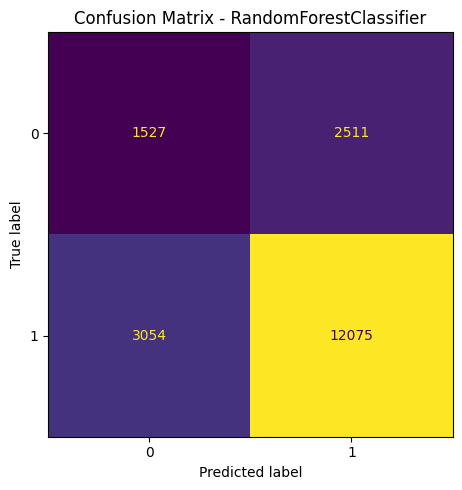

Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\plots\confusion_matrix_best_baseline_classifier.png
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\predictions\classification_best_baseline_model_test_predictions.csv


In [9]:
# =========================
# BEST BASELINE MODEL THEO MACRO-F1
# =========================
best_model_name = baseline_metrics_df.iloc[0]["model"]
best_model_pipeline = trained_baseline_pipelines[best_model_name]
best_pred_df = baseline_prediction_registry[best_model_name].copy()

print("Best baseline model (selection metric = f1_macro):", best_model_name)

best_report = classification_report(
    y_test,
    best_pred_df["y_pred"],
    output_dict=True,
    zero_division=0,
)
best_report_df = pd.DataFrame(best_report).transpose()

display(Markdown("### Classification report - best baseline model"))
display(best_report_df)

best_report_path = METRIC_DIR / f"classification_report_{best_model_name}.csv"
best_report_df.to_csv(best_report_path)
print("Đã lưu:", best_report_path)

cm = confusion_matrix(y_test, best_pred_df["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()

best_baseline_cm_plot_path = PLOT_DIR / "confusion_matrix_best_baseline_classifier.png"
plt.savefig(best_baseline_cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", best_baseline_cm_plot_path)

best_baseline_prediction_path = PRED_DIR / "classification_best_baseline_model_test_predictions.csv"
best_pred_df.to_csv(best_baseline_prediction_path, index=False)
print("Đã lưu:", best_baseline_prediction_path)


## Cell 10 — Xác định model có accuracy cao nhất

Rubric/report thường yêu cầu trình bày khách quan kết quả giữa các model.  
Cell này giữ riêng thông tin model có `accuracy` cao nhất để bạn dễ viết báo cáo:
- model tốt nhất theo accuracy
- model final được chọn theo macro-F1

Hai kết luận này có thể khác nhau và nên trình bày trung thực.


In [10]:
# =========================
# MODEL CÓ ACCURACY CAO NHẤT
# =========================
highest_accuracy_row = baseline_metrics_df.sort_values(
    ["accuracy", "f1_macro", "roc_auc"],
    ascending=[False, False, False],
).iloc[0].to_dict()

display(Markdown("### Model có accuracy cao nhất"))
display(pd.DataFrame([highest_accuracy_row]))


### Model có accuracy cao nhất

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,recall_class_0,precision_class_0,f1_class_0,recall_class_1,precision_class_1,f1_class_1,train_time_sec,fit_rows_used
0,GradientBoostingClassifier,0.792299,0.698281,0.517225,0.480611,0.623285,0.041852,0.601423,0.078259,0.992597,0.795139,0.882963,26.150356,76665


## Cell 11 — Cross-validation comparison cho 3 model lõi

Cell này chạy CV cho 3 model tabular trọng tâm:
- LogisticRegression
- RandomForestClassifier
- GradientBoostingClassifier

Mục tiêu:
- tăng độ mạnh cho phần Utilities & Evaluation
- có bảng CV comparison gọn, ít tốn thời gian hơn chạy full 5 model


In [11]:
# =========================
# CROSS-VALIDATION COMPARISON (3 CORE MODELS)
# =========================
cv_compare_models = [
    "LogisticRegression",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
]

cv_rows = []

for model_name in cv_compare_models:
    estimator = build_baseline_pipeline(clone(make_baseline_models()[model_name]))
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
            "roc_auc": "roc_auc",
        },
        n_jobs=1,
    )

    cv_rows.append({
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_precision_macro_mean": scores["test_precision_macro"].mean(),
        "cv_recall_macro_mean": scores["test_recall_macro"].mean(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
    })

cv_compare_df = pd.DataFrame(cv_rows).sort_values(
    ["cv_f1_macro_mean", "cv_roc_auc_mean"],
    ascending=[False, False],
).reset_index(drop=True)

display(Markdown("### Cross-validation comparison - core classification models"))
display(cv_compare_df)

cv_compare_path = METRIC_DIR / "classification_cv_compare_core_models.csv"
cv_compare_df.to_csv(cv_compare_path, index=False)
print("Đã lưu:", cv_compare_path)


### Cross-validation comparison - core classification models

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std
0,RandomForestClassifier,0.714107,0.002382,0.583381,0.589634,0.585957,0.004157,0.625811,0.005187
1,LogisticRegression,0.619840,0.003974,0.551118,0.572111,0.541392,0.004376,0.603109,0.005345
2,GradientBoostingClassifier,0.792578,0.000955,0.710930,0.516015,0.477510,0.003244,0.623862,0.006812


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_cv_compare_core_models.csv


## Cell 12 — Cross-validation cho best baseline model

Cell này giữ lại CV summary cho model baseline tốt nhất theo `f1_macro`.  
Bảng này hữu ích cho phần report khi bạn muốn mô tả sâu hơn model được chọn.


In [12]:
# =========================
# CROSS-VALIDATION CHO BEST BASELINE MODEL
# =========================
cv_model_name = str(best_model_name).replace("_TUNED", "")
cv_estimator = build_baseline_pipeline(clone(make_baseline_models()[cv_model_name]))
X_cv, y_cv = get_fit_data_for_model(cv_model_name, X_train, y_train)

cv_scores = cross_validate(
    cv_estimator,
    X_cv,
    y_cv,
    cv=CV_FOLDS,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "roc_auc": "roc_auc",
    },
    n_jobs=1,
)

cv_summary = pd.DataFrame({
    "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"],
    "mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision_macro"].mean(),
        cv_scores["test_recall_macro"].mean(),
        cv_scores["test_f1_macro"].mean(),
        cv_scores["test_roc_auc"].mean(),
    ],
    "std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision_macro"].std(),
        cv_scores["test_recall_macro"].std(),
        cv_scores["test_f1_macro"].std(),
        cv_scores["test_roc_auc"].std(),
    ],
})

display(Markdown("### Cross-validation summary - best baseline model"))
display(cv_summary)

cv_summary_path = METRIC_DIR / "classification_cv_summary_best_model.csv"
cv_summary.to_csv(cv_summary_path, index=False)
print("Đã lưu:", cv_summary_path)


### Cross-validation summary - best baseline model

,metric,mean,std
0,accuracy,0.714107,0.002382
1,precision_macro,0.583381,0.003842
2,recall_macro,0.589634,0.004740
3,f1_macro,0.585957,0.004157
4,roc_auc,0.625811,0.005187


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_cv_summary_best_model.csv


## Cell 13 — GridSearchCV cho best baseline model

Cell này chỉ tune **model baseline tốt nhất theo macro-F1** để:
- tiết kiệm runtime
- vẫn đáp ứng đúng rubric phần tuning

Nếu tuned model tốt hơn baseline thì notebook cập nhật `best_model_pipeline` và `best_model_name`.


In [13]:
# =========================
# GRID SEARCH CHO BEST BASELINE MODEL
# =========================
grid_search_results = pd.DataFrame()
tuned_metrics_df = pd.DataFrame()
tuned_metrics_path = None
tuned_report_path = None
grid_results_path = None
compare_path = None
best_model_path = MODEL_DIR / "best_classifier_baseline.joblib"

if RUN_GRID_SEARCH:
    search_name = str(best_model_name).replace("_TUNED", "")
    search_estimator = build_baseline_pipeline(clone(make_baseline_models()[search_name]))
    param_grid = get_param_grid(search_name)

    if param_grid:
        X_search, y_search = get_fit_data_for_model(search_name, X_train, y_train)

        print(f"Đang Grid Search cho best baseline model: {search_name}")
        grid = GridSearchCV(
            estimator=search_estimator,
            param_grid=param_grid,
            cv=GRID_SEARCH_CV,
            scoring="f1_macro",
            n_jobs=1,
            verbose=1,
        )
        grid.fit(X_search, y_search)

        best_grid_pipe = grid.best_estimator_
        print("Best params:", grid.best_params_)
        print("Best CV score:", grid.best_score_)

        tuned_pred = best_grid_pipe.predict(X_test)
        if hasattr(best_grid_pipe, "predict_proba"):
            tuned_score = best_grid_pipe.predict_proba(X_test)[:, 1]
        else:
            tuned_score = best_grid_pipe.decision_function(X_test)

        tuned_metrics_df = pd.DataFrame([{
            "model": f"{search_name}_TUNED",
            "accuracy": accuracy_score(y_test, tuned_pred),
            "precision_macro": precision_score(y_test, tuned_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, tuned_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, tuned_pred, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(y_test, tuned_score),
            "recall_class_0": recall_score(y_test, tuned_pred, pos_label=0),
            "precision_class_0": precision_score(y_test, tuned_pred, pos_label=0, zero_division=0),
            "f1_class_0": f1_score(y_test, tuned_pred, pos_label=0, zero_division=0),
            "recall_class_1": recall_score(y_test, tuned_pred, pos_label=1),
            "precision_class_1": precision_score(y_test, tuned_pred, pos_label=1, zero_division=0),
            "f1_class_1": f1_score(y_test, tuned_pred, pos_label=1, zero_division=0),
            "fit_rows_used": int(len(X_search)),
        }])

        display(Markdown("### Tuned best model metrics"))
        display(tuned_metrics_df)

        tuned_metrics_path = METRIC_DIR / "classification_grid_search_best_model.csv"
        tuned_metrics_df.to_csv(tuned_metrics_path, index=False)

        tuned_report_df = pd.DataFrame(
            classification_report(y_test, tuned_pred, output_dict=True, zero_division=0)
        ).transpose()
        tuned_report_path = METRIC_DIR / "classification_report_tuned_best_model.csv"
        tuned_report_df.to_csv(tuned_report_path)

        grid_results_path = METRIC_DIR / "classification_grid_search_cv_results.csv"
        pd.DataFrame(grid.cv_results_).to_csv(grid_results_path, index=False)

        print("Đã lưu:", tuned_metrics_path)
        print("Đã lưu:", tuned_report_path)
        print("Đã lưu:", grid_results_path)

        baseline_best_f1 = float(
            baseline_metrics_df.loc[baseline_metrics_df["model"] == search_name, "f1_macro"].iloc[0]
        )
        tuned_best_f1 = float(tuned_metrics_df.iloc[0]["f1_macro"])

        compare_df = pd.DataFrame([
            {"version": "tuned_best", "model": f"{search_name}_TUNED", "f1_macro": tuned_best_f1},
            {"version": "baseline_best", "model": search_name, "f1_macro": baseline_best_f1},
        ])
        compare_path = METRIC_DIR / "classification_baseline_vs_tuned_compare.csv"
        compare_df.to_csv(compare_path, index=False)
        display(compare_df)
        print("Đã lưu:", compare_path)

        if tuned_best_f1 >= baseline_best_f1:
            best_model_pipeline = best_grid_pipe
            best_model_name = f"{search_name}_TUNED"
            print("Tuned model tốt hơn baseline -> cập nhật best_model_pipeline")
        else:
            print("Baseline giữ nguyên vì tốt hơn tuned")

joblib.dump(best_model_pipeline, best_model_path)
print("Đã lưu best baseline path:", best_model_path)


Đang Grid Search cho best baseline model: RandomForestClassifier
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 4, 'model__n_estimators': 300, 'selector__k': 100}
Best CV score: 0.5834487905407957


### Tuned best model metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,recall_class_0,precision_class_0,f1_class_0,recall_class_1,precision_class_1,f1_class_1,fit_rows_used
0,RandomForestClassifier_TUNED,0.727709,0.587857,0.586329,0.587064,0.628047,0.342001,0.350241,0.346072,0.830656,0.825473,0.828057,76665


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_grid_search_best_model.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_report_tuned_best_model.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_grid_search_cv_results.csv


,version,model,f1_macro
0,tuned_best,RandomForestClassifier_TUNED,0.587064
1,baseline_best,RandomForestClassifier,0.583527


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_baseline_vs_tuned_compare.csv
Tuned model tốt hơn baseline -> cập nhật best_model_pipeline
Đã lưu best baseline path: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\models\best_classifier_baseline.joblib


## Cell 14 — Tạo lại artifact cho final selected model sau tuning

Đây là cell quan trọng để tránh lệch logic giữa:
- best baseline trước tuning
- final selected model sau tuning

Cell này luôn regenerate:
- final classification report
- final confusion matrix
- final prediction file
- final selected model metrics


### Final selected model metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,recall_class_0,precision_class_0,f1_class_0,recall_class_1,precision_class_1,f1_class_1
0,RandomForestClassifier_TUNED,0.727709,0.587857,0.586329,0.587064,0.628047,0.342001,0.350241,0.346072,0.830656,0.825473,0.828057


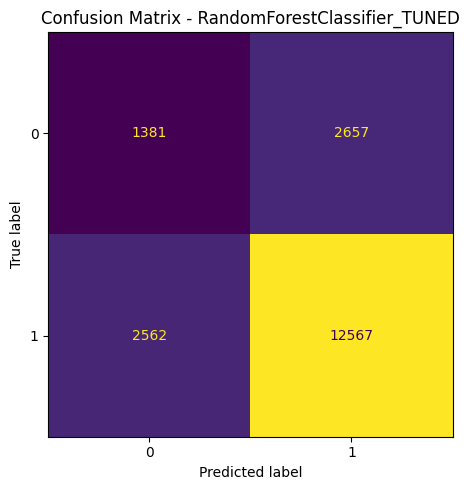

Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_final_selected_model_metrics.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_report_final_selected_model.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\predictions\classification_final_selected_model_test_predictions.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\plots\confusion_matrix_final_selected_model.png


In [14]:
# =========================
# FINAL SELECTED MODEL ARTIFACTS (SAU TUNING)
# =========================
final_model_name = best_model_name
final_model_pipe = best_model_pipeline

final_pred = final_model_pipe.predict(X_test)

if hasattr(final_model_pipe, "predict_proba"):
    final_score = final_model_pipe.predict_proba(X_test)[:, 1]
else:
    final_score = final_model_pipe.decision_function(X_test)

final_pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": final_pred,
    "y_score": final_score,
})

final_selected_metrics_df = pd.DataFrame([{
    "model": final_model_name,
    "accuracy": accuracy_score(y_test, final_pred),
    "precision_macro": precision_score(y_test, final_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, final_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, final_pred, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, final_score),
    "recall_class_0": recall_score(y_test, final_pred, pos_label=0),
    "precision_class_0": precision_score(y_test, final_pred, pos_label=0, zero_division=0),
    "f1_class_0": f1_score(y_test, final_pred, pos_label=0, zero_division=0),
    "recall_class_1": recall_score(y_test, final_pred, pos_label=1),
    "precision_class_1": precision_score(y_test, final_pred, pos_label=1, zero_division=0),
    "f1_class_1": f1_score(y_test, final_pred, pos_label=1, zero_division=0),
}])

display(Markdown("### Final selected model metrics"))
display(final_selected_metrics_df)

final_selected_metrics_path = METRIC_DIR / "classification_final_selected_model_metrics.csv"
final_selected_metrics_df.to_csv(final_selected_metrics_path, index=False)

final_report_df = pd.DataFrame(
    classification_report(y_test, final_pred, output_dict=True, zero_division=0)
).transpose()

final_report_path = METRIC_DIR / "classification_report_final_selected_model.csv"
final_report_df.to_csv(final_report_path)

final_prediction_path = PRED_DIR / "classification_final_selected_model_test_predictions.csv"
final_pred_df.to_csv(final_prediction_path, index=False)

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()

final_cm_plot_path = PLOT_DIR / "confusion_matrix_final_selected_model.png"
plt.savefig(final_cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", final_selected_metrics_path)
print("Đã lưu:", final_report_path)
print("Đã lưu:", final_prediction_path)
print("Đã lưu:", final_cm_plot_path)


## Cell 15 — Random Forest feature importance

Cell này được thêm để khớp tốt hơn với mẫu báo cáo cuối kỳ.  
Nếu final selected model không phải Random Forest, notebook vẫn lấy pipeline Random Forest baseline để xuất:
- bảng importance
- plot Top 20 features


### Random Forest feature importance

,feature,importance
0,num__freight_value_sum,0.135793
1,num__payment_value_sum,0.118529
2,num__basket_value,0.117543
3,num__price_sum,0.111098
4,num__purchase_month,0.098146
5,num__purchase_dayofweek,0.059178
6,num__payment_installments_max,0.047713
7,num__item_count,0.035823
8,num__purchase_year,0.018752
9,num__unique_products,0.017973


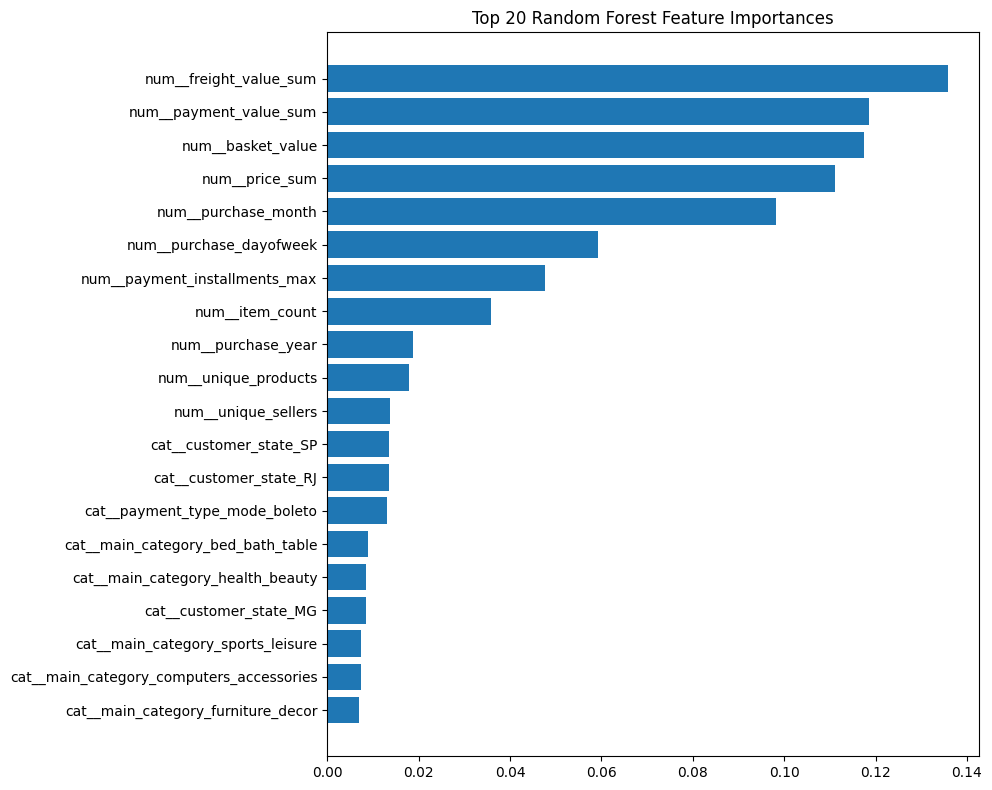

Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_random_forest_feature_importance.csv
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\plots\classification_random_forest_feature_importance.png


In [15]:
# =========================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================
if "RandomForestClassifier" in str(best_model_name):
    rf_pipe = best_model_pipeline
else:
    rf_pipe = trained_baseline_pipelines["RandomForestClassifier"]

rf_model = rf_pipe.named_steps["model"]
rf_feature_names = get_selected_feature_names(rf_pipe)

fi_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(Markdown("### Random Forest feature importance"))
display(fi_df.head(20))

fi_path = METRIC_DIR / "classification_random_forest_feature_importance.csv"
fi_df.to_csv(fi_path, index=False)

plot_df = fi_df.head(20).sort_values("importance", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()

fi_plot_path = PLOT_DIR / "classification_random_forest_feature_importance.png"
plt.savefig(fi_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", fi_path)
print("Đã lưu:", fi_plot_path)


## Cell 16 — ROC curve comparison cho 5 model tabular baseline

Cell này vẽ ROC curve để:
- khớp phần utilities/evaluation
- hỗ trợ hình cho báo cáo cuối kỳ

ROC chỉ vẽ cho 5 model baseline bắt buộc của rubric.


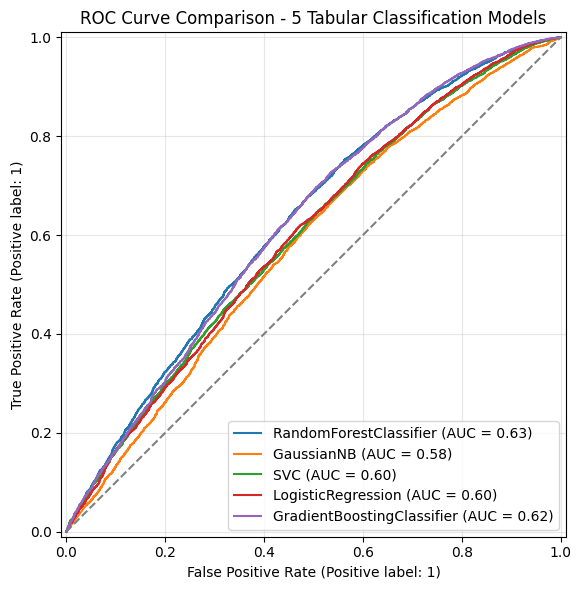

Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\plots\roc_curve_comparison_baseline_models.png


In [16]:
# =========================
# ROC CURVE SO SÁNH 5 MODEL TABULAR
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in baseline_metrics_df["model"].tolist():
    if model_name not in baseline_score_registry:
        continue
    y_score = baseline_score_registry[model_name]
    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve Comparison - 5 Tabular Classification Models")
ax.grid(alpha=0.3)
plt.tight_layout()

roc_plot_path = PLOT_DIR / "roc_curve_comparison_baseline_models.png"
plt.savefig(roc_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", roc_plot_path)


## Cell 17 — Text classification với TF-IDF (module bổ sung)

Cell này giữ nhánh text classification để tăng chiều sâu cho:
- báo cáo
- app prediction text

Nhánh này **không thay thế** bộ 5 model tabular bắt buộc của rubric.


In [17]:
# =========================
# TEXT CLASSIFICATION (BỔ SUNG CHO REPORT / APP)
# =========================
text_df = df[[TEXT_COL, TARGET_BIN_COL]].copy()
text_df[TEXT_COL] = text_df[TEXT_COL].fillna("").astype(str).str.strip()
text_df = text_df.dropna(subset=[TARGET_BIN_COL]).copy()

X_text = text_df[TEXT_COL]
y_text = text_df[TARGET_BIN_COL].astype(int)

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text,
    y_text,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_text,
)

text_models = {
    "TFIDF_LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, min_df=5, max_df=0.95, ngram_range=(1, 2))),
        ("model", LogisticRegression(
            C=2.0,
            solver="liblinear",
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "TFIDF_LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, min_df=5, max_df=0.95, ngram_range=(1, 2))),
        ("model", LinearSVC(
            C=2.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
}

text_results = []
trained_text_pipelines = {}

for model_name, pipe in text_models.items():
    print(f"\n===== {model_name} =====")
    start = time.time()
    pipe.fit(X_text_train, y_text_train)
    train_time = time.time() - start

    y_pred = pipe.predict(X_text_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_text_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_text_test)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_text_test, y_pred),
        "precision_macro": precision_score(y_text_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_text_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_text_test, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_text_test, y_score),
        "train_time_sec": train_time,
    }
    text_results.append(result)
    trained_text_pipelines[model_name] = pipe
    print(pd.Series(result))

text_metrics_df = pd.DataFrame(text_results).sort_values(
    ["f1_macro", "roc_auc", "accuracy"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(Markdown("### Text TF-IDF metrics"))
display(text_metrics_df)

text_metrics_path = METRIC_DIR / "classification_metrics_text_tfidf.csv"
text_metrics_df.to_csv(text_metrics_path, index=False)
print("Đã lưu:", text_metrics_path)

best_text_model_name = text_metrics_df.iloc[0]["model"]
best_text_pipeline = trained_text_pipelines[best_text_model_name]
best_text_model_path = MODEL_DIR / "best_classifier_text_tfidf.joblib"
joblib.dump(best_text_pipeline, best_text_model_path)

print("Best text model:", best_text_model_name)
print("Đã lưu:", best_text_model_path)



===== TFIDF_LogisticRegression =====
model              TFIDF_LogisticRegression
accuracy                           0.868406
precision_macro                    0.836481
recall_macro                       0.768119
f1_macro                           0.793974
roc_auc                            0.819664
train_time_sec                     1.360305
dtype: object

===== TFIDF_LinearSVC =====
model              TFIDF_LinearSVC
accuracy                  0.866785
precision_macro           0.839643
recall_macro              0.758764
f1_macro                  0.787722
roc_auc                   0.811304
train_time_sec            1.613739
dtype: object


### Text TF-IDF metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,train_time_sec
0,TFIDF_LogisticRegression,0.868406,0.836481,0.768119,0.793974,0.819664,1.360305
1,TFIDF_LinearSVC,0.866785,0.839643,0.758764,0.787722,0.811304,1.613739


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_metrics_text_tfidf.csv
Best text model: TFIDF_LogisticRegression
Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\models\best_classifier_text_tfidf.joblib


## Cell 18 — Tổng hợp final summary

Cell này ghi `classification_final_summary.json` với thông tin quan trọng cho:
- app
- dashboard
- integration
- báo cáo cuối kỳ


In [18]:
# =========================
# FINAL SUMMARY
# =========================
highest_accuracy_row = baseline_metrics_df.sort_values(
    ["accuracy", "f1_macro", "roc_auc"],
    ascending=[False, False, False],
).iloc[0].to_dict()

if str(best_model_name).endswith("_TUNED") and not tuned_metrics_df.empty:
    best_baseline_f1_for_summary = float(tuned_metrics_df.iloc[0]["f1_macro"])
else:
    base_name = str(best_model_name).replace("_TUNED", "")
    best_baseline_f1_for_summary = float(
        baseline_metrics_df.loc[baseline_metrics_df["model"] == base_name, "f1_macro"].iloc[0]
    )

summary_payload = {
    "raw_target_column": TARGET_COL,
    "model_target_column": TARGET_BIN_COL,
    "target_definition": "review_label = 1 if review_score >= 4 else 0",
    "baseline_models_rubric": [
        "LogisticRegression",
        "RandomForestClassifier",
        "GaussianNB",
        "SVC",
        "GradientBoostingClassifier",
    ],
    "strict_deployable_feature_set": True,
    "scaler_note": "MinMaxScaler được dùng vì SelectKBest(chi2) yêu cầu input không âm.",
    "best_model_selection_metric": "f1_macro",
    "best_baseline_model": best_model_name,
    "best_baseline_f1_macro": best_baseline_f1_for_summary,
    "highest_accuracy_model": highest_accuracy_row["model"],
    "highest_accuracy": float(highest_accuracy_row["accuracy"]),
    "best_text_model": best_text_model_name,
    "best_text_f1_macro": float(text_metrics_df.iloc[0]["f1_macro"]),
    "n_numeric_features": int(len(numeric_features)),
    "n_categorical_features": int(len(categorical_features)),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "k_best_selected_features": int(k_best),
    "baseline_metrics_file": str(baseline_metrics_path),
    "cv_compare_file": str(cv_compare_path),
    "cv_summary_file": str(cv_summary_path),
    "best_baseline_model_file": str(best_model_path),
    "final_selected_model_metrics_file": str(final_selected_metrics_path),
    "final_selected_model_report_file": str(final_report_path),
    "final_selected_prediction_file": str(final_prediction_path),
    "final_selected_confusion_matrix_file": str(final_cm_plot_path),
    "random_forest_feature_importance_file": str(fi_path),
    "random_forest_feature_importance_plot_file": str(fi_plot_path),
    "text_metrics_file": str(text_metrics_path),
    "best_text_model_file": str(best_text_model_path),
    "roc_curve_plot_file": str(roc_plot_path),
    "grid_search_metrics_file": str(tuned_metrics_path) if tuned_metrics_path else None,
    "grid_search_report_file": str(tuned_report_path) if tuned_report_path else None,
    "grid_search_cv_results_file": str(grid_results_path) if grid_results_path else None,
    "baseline_vs_tuned_compare_file": str(compare_path) if compare_path else None,
}

summary_path = METRIC_DIR / "classification_final_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

display(Markdown("### Classification final summary"))
display(pd.DataFrame([summary_payload]))

print("Đã lưu:", summary_path)


### Classification final summary

,raw_target_column,model_target_column,target_definition,baseline_models_rubric,strict_deployable_feature_set,scaler_note,best_model_selection_metric,best_baseline_model,best_baseline_f1_macro,highest_accuracy_model,...,final_selected_confusion_matrix_file,random_forest_feature_importance_file,random_forest_feature_importance_plot_file,text_metrics_file,best_text_model_file,roc_curve_plot_file,grid_search_metrics_file,grid_search_report_file,grid_search_cv_results_file,baseline_vs_tuned_compare_file
0,review_score,review_label,review_label = 1 if review_score >= 4 else 0,"[LogisticRegression, RandomForestClassifier, G...",True,MinMaxScaler được dùng vì SelectKBest(chi2) yê...,f1_macro,RandomForestClassifier_TUNED,0.587064,GradientBoostingClassifier,...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...,C:\Users\trant\OneDrive\Tài liệu\Documents\U...


Đã lưu: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\artifacts\metrics\classification_final_summary.json


## CHECK-IN — FILE 03: `03_classification_pipeline.ipynb`

### A. THIẾT LẬP BAN ĐẦU
- [x] Hoàn thành import thư viện cho classification pipeline
- [x] Hoàn thành cấu hình cảnh báo
- [x] Hoàn thành resolve `BASE_DIR`
- [x] Hoàn thành resolve `PROCESSED_DIR`
- [x] Hoàn thành resolve `ARTIFACT_DIR`
- [x] Hoàn thành cấu hình guard cho SVC runtime

---

### B. ĐỌC DỮ LIỆU ĐẦU VÀO
- [x] Hoàn thành đọc dữ liệu đầu vào từ processed dataset
- [x] Hoàn thành hiển thị sample dữ liệu đầu vào
- [x] Hoàn thành kiểm tra shape dữ liệu đầu vào
- [x] Hoàn thành xác nhận dữ liệu đầu vào sẵn sàng cho classification

---

### C. CHUẨN HÓA TARGET CLASSIFICATION
- [x] Hoàn thành chọn target raw `review_score`
- [x] Hoàn thành tạo target classification `review_label`
- [x] Hoàn thành thống kê phân bố `review_score`
- [x] Hoàn thành thống kê phân bố `review_label`
- [x] Hoàn thành tính tỷ lệ phần trăm các lớp của `review_label`

---

### D. CHỌN FEATURE TABULAR THEO HƯỚNG DEPLOYABLE
- [x] Hoàn thành khai báo danh sách numeric candidate features
- [x] Hoàn thành khai báo danh sách categorical candidate features
- [x] Hoàn thành khai báo `blocked_cols`
- [x] Hoàn thành lọc ra `numeric_features`
- [x] Hoàn thành lọc ra `categorical_features`
- [x] Hoàn thành tạo `feature_cols`
- [x] Hoàn thành hiển thị danh sách numeric features
- [x] Hoàn thành hiển thị danh sách categorical features
- [x] Hoàn thành đếm tổng số feature baseline tabular

---

### E. TẠO DATASET TRAIN / TEST CHO TABULAR CLASSIFICATION
- [x] Hoàn thành tạo `X`
- [x] Hoàn thành tạo `y`
- [x] Hoàn thành train/test split cho classification
- [x] Hoàn thành dùng `stratify=y`
- [x] Hoàn thành in shape của train set
- [x] Hoàn thành in shape của test set

---

### F. XÂY DỰNG PREPROCESSOR VÀ FEATURE SELECTION
- [x] Hoàn thành xây dựng preprocessor cho numeric features
- [x] Hoàn thành xây dựng preprocessor cho categorical features
- [x] Hoàn thành sử dụng `ColumnTransformer`
- [x] Hoàn thành sử dụng `SimpleImputer`
- [x] Hoàn thành sử dụng `MinMaxScaler`
- [x] Hoàn thành sử dụng `OneHotEncoder`
- [x] Hoàn thành `fit_transform()` trên tập train
- [x] Hoàn thành tạo `SelectKBest`
- [x] Hoàn thành sử dụng `chi2`
- [x] Hoàn thành chọn `k_best`
- [x] Hoàn thành lấy danh sách feature sau transform
- [x] Hoàn thành hiển thị transformed shape
- [x] Hoàn thành hiển thị danh sách feature sau transform

---

### G. HÀM TIỆN ÍCH / PIPELINE FACTORY / MODEL FACTORY / PARAM GRID
- [x] Hoàn thành khai báo các hàm tiện ích phục vụ train/evaluate
- [x] Hoàn thành khai báo hàm build pipeline cho model
- [x] Hoàn thành khai báo model factory
- [x] Hoàn thành khai báo param grid cho tuning
- [x] Hoàn thành chuẩn bị logic dùng chung cho baseline / CV / GridSearchCV

---

### H. TRAIN VÀ ĐÁNH GIÁ 5 MODEL TABULAR BASELINE
- [x] Hoàn thành train `LogisticRegression`
- [x] Hoàn thành train `RandomForestClassifier`
- [x] Hoàn thành train `GaussianNB`
- [x] Hoàn thành train `SVC`
- [x] Hoàn thành train `GradientBoostingClassifier`

- [x] Hoàn thành tính các metric cho từng model:
  - `accuracy`
  - `precision_macro`
  - `recall_macro`
  - `f1_macro`
  - `roc_auc`
  - `recall_class_0`
  - `precision_class_0`
  - `f1_class_0`
  - `recall_class_1`
  - `precision_class_1`
  - `f1_class_1`
  - `train_time_sec`

- [x] Hoàn thành tổng hợp `baseline_metrics_df`
- [x] Hoàn thành hiển thị bảng kết quả baseline tabular

---

### I. PHÂN TÍCH BEST BASELINE MODEL
- [x] Hoàn thành chọn best baseline model theo `f1_macro`
- [x] Hoàn thành tạo classification report cho best baseline model
- [x] Hoàn thành hiển thị classification report
- [x] Hoàn thành vẽ confusion matrix cho best baseline model
- [x] Hoàn thành tạo file predictions cho best baseline model
- [x] Hoàn thành lưu classification report của best baseline model
- [x] Hoàn thành lưu confusion matrix của best baseline model
- [x] Hoàn thành lưu predictions của best baseline model

---

### J. XÁC ĐỊNH MODEL CÓ ACCURACY CAO NHẤT
- [x] Hoàn thành xác định model baseline có accuracy cao nhất
- [x] Hoàn thành hiển thị thông tin model có accuracy cao nhất

---

### K. CROSS-VALIDATION COMPARISON CHO 3 MODEL LÕI
- [x] Hoàn thành cross-validation cho `RandomForestClassifier`
- [x] Hoàn thành cross-validation cho `LogisticRegression`
- [x] Hoàn thành cross-validation cho `GradientBoostingClassifier`
- [x] Hoàn thành tổng hợp bảng so sánh CV cho 3 model lõi
- [x] Hoàn thành tính:
  - `cv_accuracy_mean`
  - `cv_accuracy_std`
  - `cv_precision_macro_mean`
  - `cv_recall_macro_mean`
  - `cv_f1_macro_mean`
  - `cv_f1_macro_std`
  - `cv_roc_auc_mean`
  - `cv_roc_auc_std`
- [x] Hoàn thành lưu file `classification_cv_compare_core_models.csv`

---

### L. CROSS-VALIDATION CHO BEST BASELINE MODEL
- [x] Hoàn thành cross-validation cho best baseline model
- [x] Hoàn thành tổng hợp CV summary của best baseline model
- [x] Hoàn thành hiển thị bảng CV summary
- [x] Hoàn thành lưu file `classification_cv_summary_best_model.csv`

---

### M. GRIDSEARCHCV CHO BEST BASELINE MODEL
- [x] Hoàn thành chạy `GridSearchCV` cho best baseline model
- [x] Hoàn thành tìm `best_params`
- [x] Hoàn thành lấy `best CV score`
- [x] Hoàn thành đánh giá tuned model trên test set
- [x] Hoàn thành tính metrics cho tuned model
- [x] Hoàn thành tạo classification report cho tuned model
- [x] Hoàn thành tổng hợp bảng so sánh `baseline_vs_tuned`
- [x] Hoàn thành cập nhật `best_model_pipeline` khi tuned model tốt hơn baseline

- [x] Hoàn thành lưu:
  - `classification_grid_search_best_model.csv`
  - `classification_report_tuned_best_model.csv`
  - `classification_grid_search_cv_results.csv`
  - `classification_baseline_vs_tuned_compare.csv`
  - `best_classifier_baseline.joblib`

---

### N. TẠO LẠI ARTIFACT CHO FINAL SELECTED MODEL SAU TUNING
- [x] Hoàn thành chọn `final_model_name`
- [x] Hoàn thành đánh giá final selected model trên test set
- [x] Hoàn thành tạo metrics cho final selected model
- [x] Hoàn thành tạo classification report cho final selected model
- [x] Hoàn thành tạo confusion matrix cho final selected model
- [x] Hoàn thành tạo predictions cho final selected model
- [x] Hoàn thành lưu:
  - `classification_final_selected_model_metrics.csv`
  - `classification_report_final_selected_model.csv`
  - `classification_final_selected_model_test_predictions.csv`
  - `confusion_matrix_final_selected_model.png`

---

### O. RANDOM FOREST FEATURE IMPORTANCE
- [x] Hoàn thành lấy feature importance của Random Forest
- [x] Hoàn thành tạo bảng feature importance
- [x] Hoàn thành vẽ biểu đồ feature importance
- [x] Hoàn thành lưu:
  - `classification_random_forest_feature_importance.csv`
  - `classification_random_forest_feature_importance.png`

---

### P. ROC CURVE COMPARISON
- [x] Hoàn thành vẽ ROC curve comparison cho 5 model tabular baseline
- [x] Hoàn thành lưu `roc_curve_comparison_baseline_models.png`

---

### Q. TEXT CLASSIFICATION VỚI TF-IDF (MODULE BỔ SUNG)
- [x] Hoàn thành xây dựng branch text classification với TF-IDF
- [x] Hoàn thành train `TFIDF_LogisticRegression`
- [x] Hoàn thành train `TFIDF_LinearSVC`
- [x] Hoàn thành tính metrics cho text models:
  - `accuracy`
  - `precision_macro`
  - `recall_macro`
  - `f1_macro`
  - `roc_auc`
  - `train_time_sec`
- [x] Hoàn thành tổng hợp `text_metrics_df`
- [x] Hoàn thành chọn best text model
- [x] Hoàn thành lưu:
  - `classification_metrics_text_tfidf.csv`
  - `best_classifier_text_tfidf.joblib`

---

### R. TỔNG HỢP FINAL SUMMARY
- [x] Hoàn thành tạo `summary_payload`
- [x] Hoàn thành tổng hợp các thông tin:
  - raw target column
  - model target column
  - target definition
  - baseline models theo rubric
  - strict deployable feature set
  - scaler note
  - best model selection metric
  - best baseline model
  - best baseline f1_macro
  - highest accuracy model
  - file confusion matrix cuối
  - file feature importance
  - file text metrics
  - file best text model
  - file ROC curve
  - file grid search metrics
  - file grid search report
  - file grid search CV results
  - file baseline vs tuned compare
- [x] Hoàn thành lưu `classification_final_summary.json`

---

### S. HƯỚNG DẪN VIẾT BÁO CÁO / BẢO VỆ
- [x] Hoàn thành phần markdown gợi ý viết báo cáo / bảo vệ cho notebook classification

---

### T. KẾT LUẬN CHECK-IN
- [x] Hoàn thành phần **đọc dữ liệu đầu vào**
- [x] Hoàn thành phần **chuẩn hóa target classification**
- [x] Hoàn thành phần **chọn feature tabular deployable**
- [x] Hoàn thành phần **train/test split**
- [x] Hoàn thành phần **preprocessor + feature selection**
- [x] Hoàn thành phần **train và đánh giá 5 model baseline**
- [x] Hoàn thành phần **classification report + confusion matrix**
- [x] Hoàn thành phần **xác định best baseline model**
- [x] Hoàn thành phần **xác định model có accuracy cao nhất**
- [x] Hoàn thành phần **cross-validation comparison**
- [x] Hoàn thành phần **GridSearchCV**
- [x] Hoàn thành phần **final selected model sau tuning**
- [x] Hoàn thành phần **Random Forest feature importance**
- [x] Hoàn thành phần **ROC curve comparison**
- [x] Hoàn thành phần **text classification với TF-IDF**
- [x] Hoàn thành phần **final summary artifact**
- [x] Hoàn thành phần **artifact save / export cho classification**

### Kết luận cuối:
Notebook `03_classification_pipeline_fixed_completed.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **Classification Pipeline, Baseline Comparison, Cross-Validation, GridSearchCV, Final Model Selection, ROC/Confusion Matrix, Feature Importance, và TF-IDF Text Classification** của riêng file này.